I. Data Understanding

In [40]:
import numpy as np
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
dataset = pd.read_csv('diabetes_data_upload.csv')
dataset

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


II. DATA PREPARATION

1. Exploratory Data Analysis

In [42]:
dataset.columns # inspeksi daftar variabel

Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='object')

In [43]:
dataset.info() # must!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [44]:
dataset.isna().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

In [45]:
dataset.duplicated().sum()

np.int64(269)

In [46]:
dataset.describe()

,Age
count,520.000000
mean,48.028846
std,12.151466
min,16.000000
25%,39.000000
50%,47.500000
75%,57.000000
max,90.000000


In [47]:
map_target = {"Positive" : 1, "Negative" : 0}
map_yes_no = {'Yes' : 1, 'No' : 0}
map_gender = {'Female' : 1, 'Male' : 0}

dataset['class'] = dataset['class'].map(map_target)
cols = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity']
dataset['Gender'] = dataset['Gender'].map(map_gender)
dataset[cols] = dataset[cols].replace(map_yes_no)

C:\Users\USER\AppData\Local\Temp\ipykernel_16532\1124265964.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset[cols] = dataset[cols].replace(map_yes_no)


In [48]:
target_count = dataset['class'].value_counts()
target_count

class
1    320
0    200
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_16532\3594608812.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=dataset, palette="coolwarm")


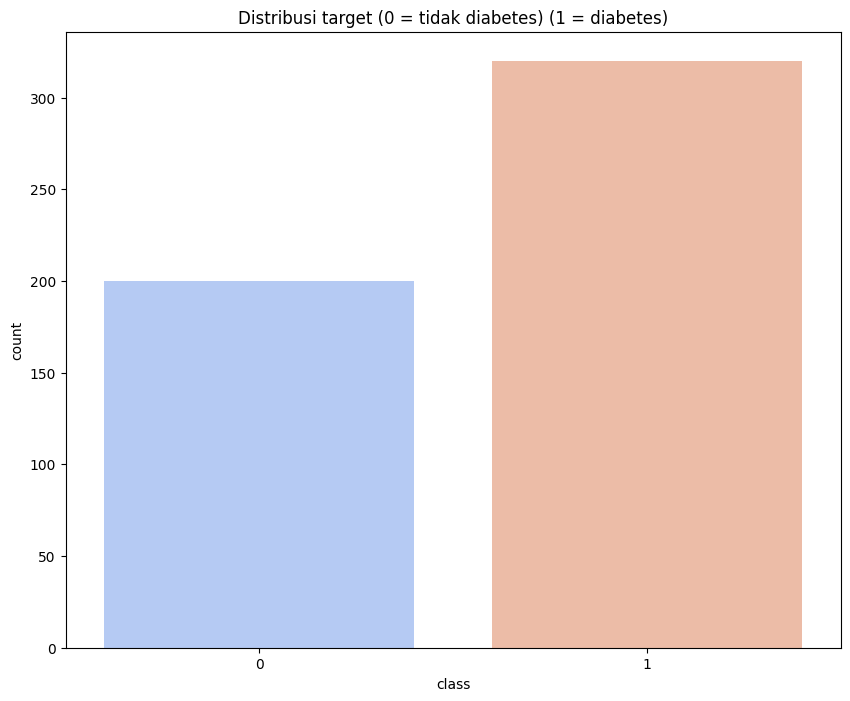

In [49]:
plt.figure(figsize=(10,8))
sns.countplot(x="class", data=dataset, palette="coolwarm")
plt.title("Distribusi target (0 = tidak diabetes) (1 = diabetes)")
plt.show()

In [ ]:
def check_value(cols):
    for col in cols:
        print(f'Kolom: {col}')
        print(dataset[col].value_counts())
        print(f'\n')

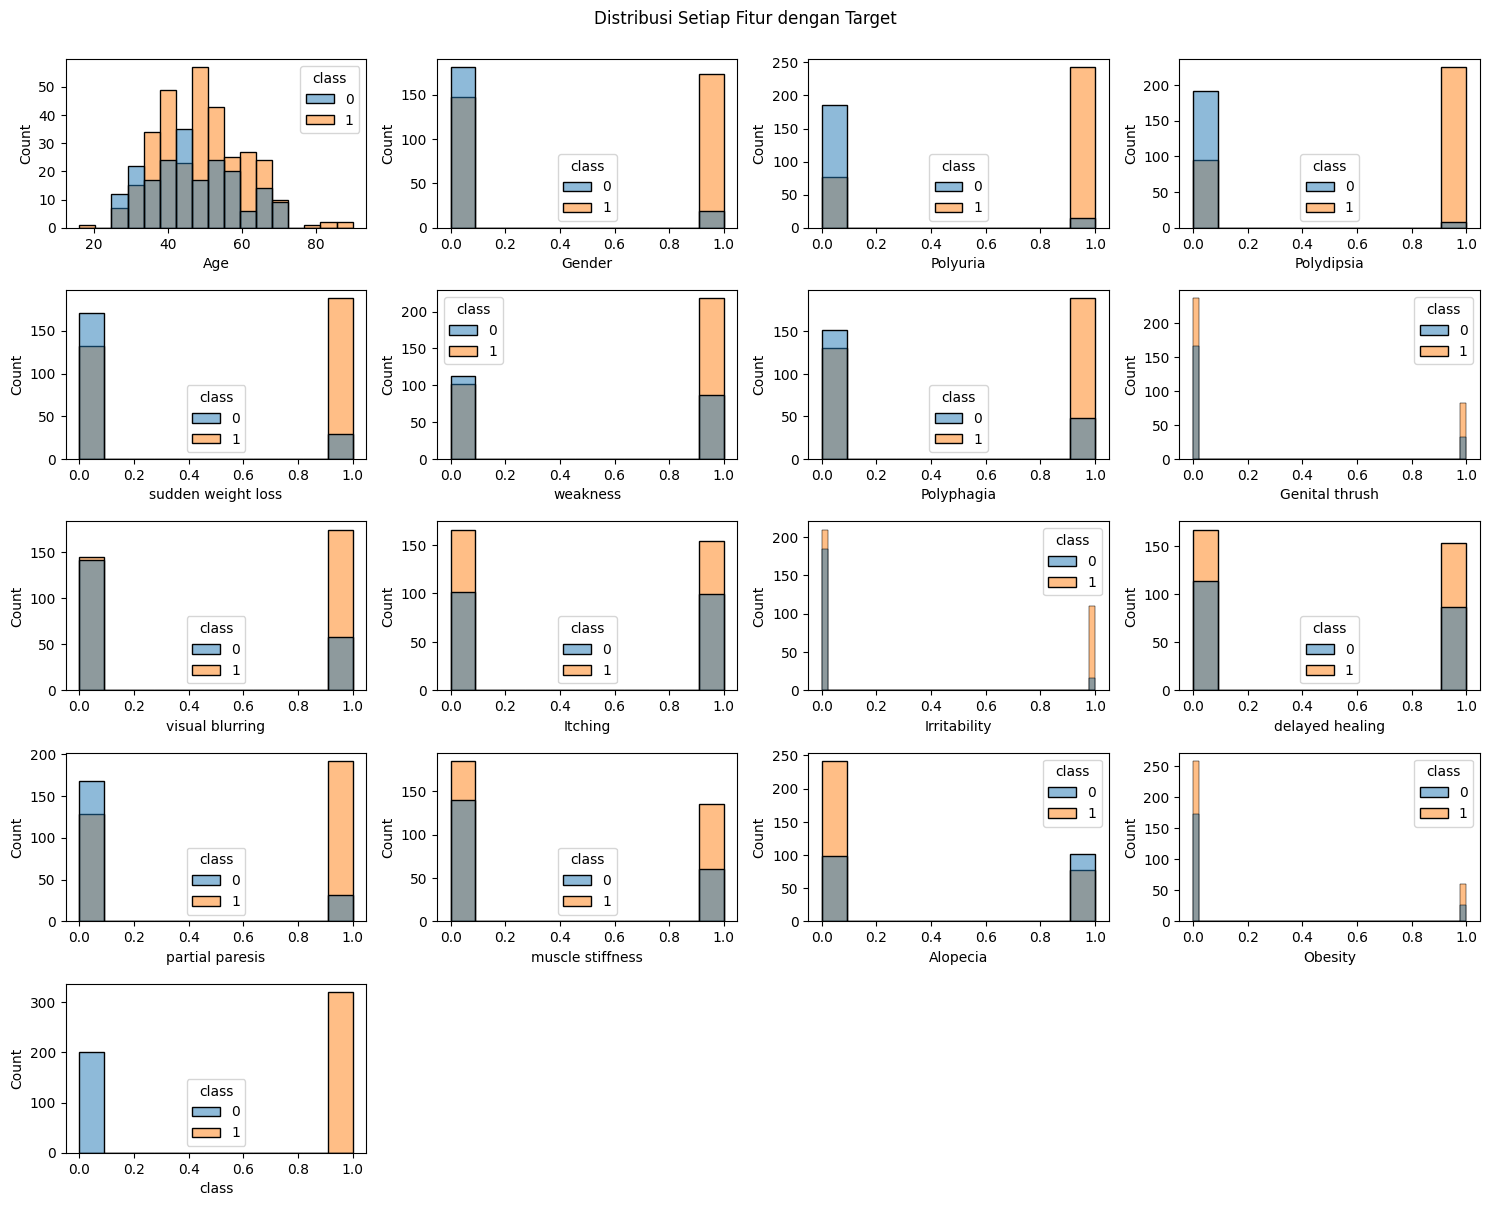

In [51]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["class"])

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1.001)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_16532\3023512700.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="MutualInformation", y="Feature", data=mi_df, palette="viridis")


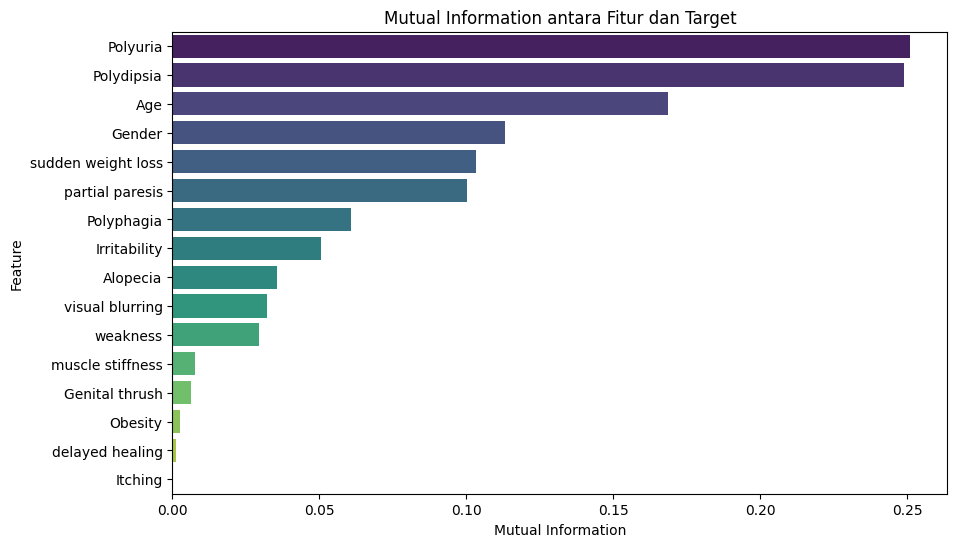

In [52]:
def mutual_information(X, y):
    joint_prob = pd.crosstab(X, y, normalize=True)

    px = joint_prob.sum(axis=1)
    py = joint_prob.sum(axis=0)

    mi = 0
    for i in joint_prob.index:
        for j in joint_prob.columns:
            pxy = joint_prob.loc[i, j]
            if pxy > 0:
                mi += pxy * np.log(pxy / (px[i] * py[j]))
    return mi

mi_scores = []
for col in dataset.drop("class", axis=1).columns:
    mi_val = mutual_information(dataset[col], dataset["class"])
    mi_scores.append((col, mi_val))

mi_df = pd.DataFrame(mi_scores, columns=["Feature", "MutualInformation"])
mi_df = mi_df.sort_values(by="MutualInformation", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="MutualInformation", y="Feature", data=mi_df, palette="viridis")
plt.title("Mutual Information antara Fitur dan Target")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.show()


Kendall Correlation Matrix:
class                 1.000000
Polyuria              0.665922
Polydipsia            0.648734
Gender                0.449233
sudden weight loss    0.436568
partial paresis       0.432288
Polyphagia            0.342504
Irritability          0.299467
visual blurring       0.251300
weakness              0.243275
muscle stiffness      0.122474
Genital thrush        0.110288
Age                   0.091003
Obesity               0.072173
delayed healing       0.046980
Itching              -0.013384
Alopecia             -0.267512
Name: class, dtype: float64


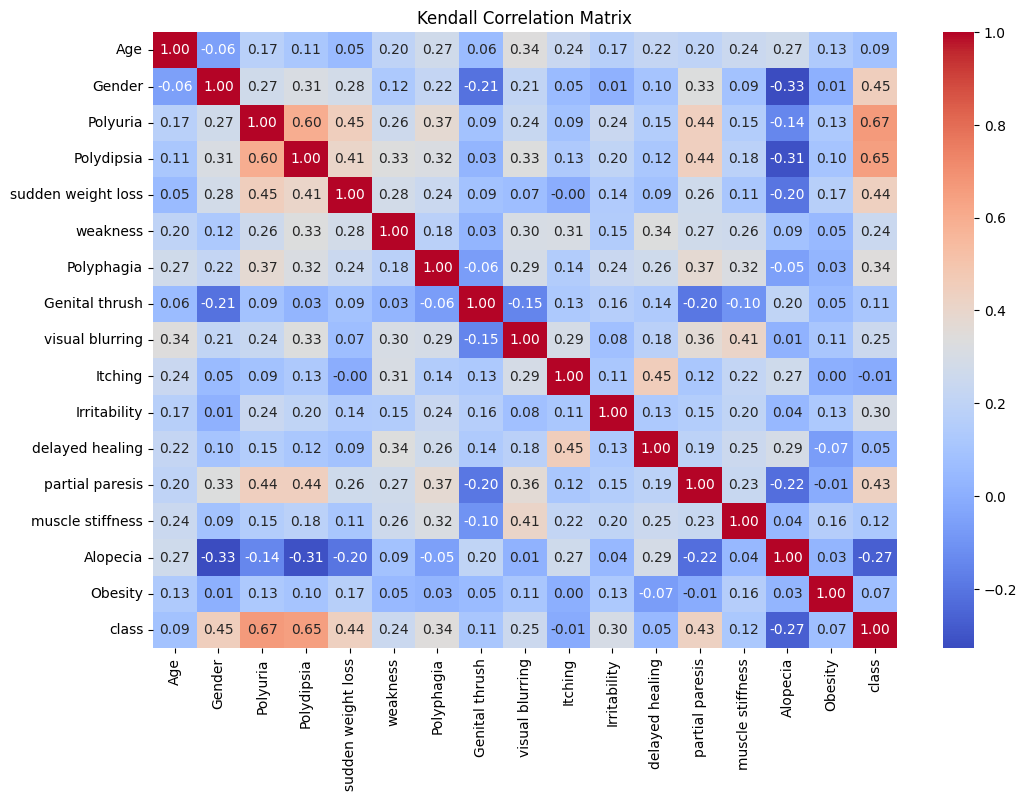

In [53]:
kendall_corr = dataset.corr(method="kendall")
print("\nKendall Correlation Matrix:")
print(kendall_corr["class"].sort_values(ascending=False))

plt.figure(figsize=(12,8))
sns.heatmap(kendall_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Kendall Correlation Matrix")
plt.show()

               Feature        Chi2  DOF
2             Polyuria  230.595375    1
3           Polydipsia  218.844836    1
0                  Age  145.786354   50
1               Gender  104.941517    1
4   sudden weight loss   99.107725    1
12     partial paresis   97.173745    1
6           Polyphagia   61.000626    1
10        Irritability   46.633873    1
14            Alopecia   37.212471    1
8      visual blurring   32.838944    1
5             weakness   30.774960    1
13    muscle stiffness    7.800000    1
7       Genital thrush    6.324962    1
15             Obesity    2.708675    1
11     delayed healing    1.147679    1
9              Itching    0.093144    1


C:\Users\USER\AppData\Local\Temp\ipykernel_16532\70225808.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Chi2", y="Feature", data=results_dataset.sort_values(by="Chi2", ascending=False), palette="magma")


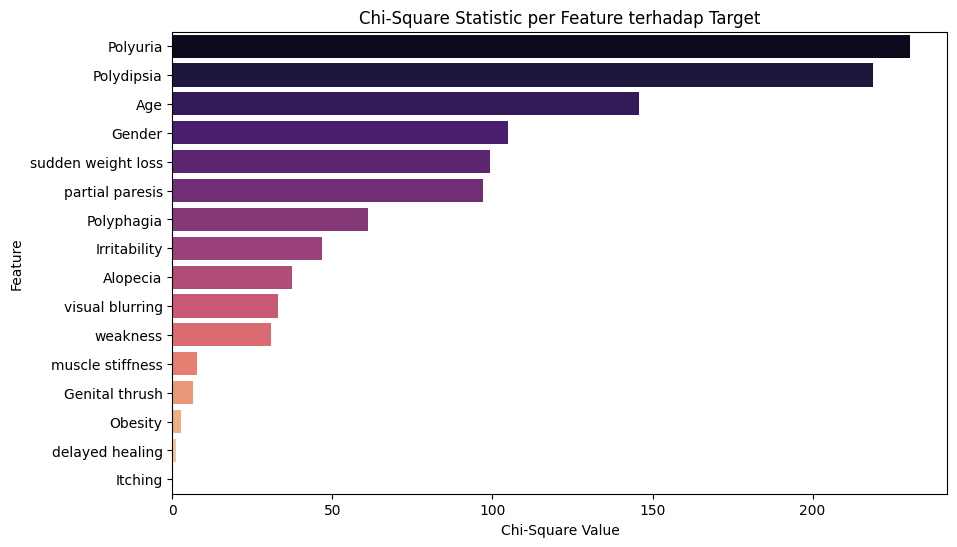

In [54]:
def chi_square_test(col, target):
    table = pd.crosstab(col, target)
    observed = table.values
    total = observed.sum()

    row_sum = observed.sum(axis=1).reshape(-1,1)
    col_sum = observed.sum(axis=0).reshape(1,-1)
    expected = row_sum.dot(col_sum) / total

    chi2 = ((observed - expected)**2 / expected).sum()
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)
    return chi2, dof

categorical_cols = dataset.drop("class", axis=1).columns

results = []  
for col in categorical_cols:
    chi2, dof = chi_square_test(dataset[col], dataset["class"])
    results.append((col, chi2, dof))

results_dataset = pd.DataFrame(results, columns=["Feature", "Chi2", "DOF"])
print(results_dataset.sort_values(by="Chi2", ascending=False))

plt.figure(figsize=(10,6))
sns.barplot(x="Chi2", y="Feature", data=results_dataset.sort_values(by="Chi2", ascending=False), palette="magma")
plt.title("Chi-Square Statistic per Feature terhadap Target")
plt.xlabel("Chi-Square Value")
plt.ylabel("Feature")
plt.show()

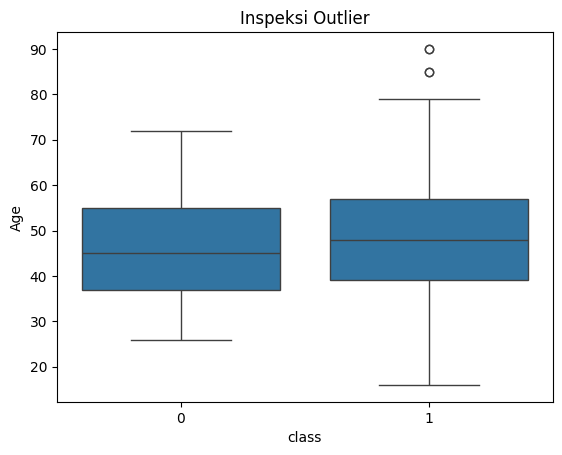

In [55]:
sns.boxplot(data=dataset, x="class", y="Age")
plt.title("Inspeksi Outlier")
plt.show()

2. Feature Selection

In [56]:
feature_cols = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'Itching', 'delayed healing', 'partial paresis']

3. Data Preprocessing

In [57]:
dataset_used = dataset[feature_cols].copy()

In [58]:
# isi missing value dgn median untuk numerik
for col in dataset_used.columns:
    if dataset_used[col].dtypes in [np.int64, np.float64]:
        median_val = dataset_used[col].median()
        dataset_used[col].fillna(median_val, inplace=True)
    else:
        dataset_used[col].fillna(dataset_used[col].mode()[0], inplace=True)

numerical_features = dataset_used.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [f for f in numerical_features if f != "class"]
for col in numerical_features:
    min_val = dataset_used[col].min()
    max_val = dataset_used[col].max()
    dataset_used[col] = (dataset_used[col] - min_val) / (max_val - min_val)

C:\Users\USER\AppData\Local\Temp\ipykernel_16532\848381086.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset_used[col].fillna(median_val, inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_16532\848381086.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [59]:
dataset

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,0,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,0,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,0,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,1,1,1,1,0,1,0,0,1,0,1,1,0,0,0,1
516,48,1,1,1,1,1,1,0,0,1,1,1,1,0,0,0,1
517,58,1,1,1,1,1,1,0,1,0,0,0,1,1,0,1,1
518,32,1,0,0,0,1,0,0,1,1,0,1,0,0,1,0,0


4. Spliting Dataset

In [60]:
print(dataset_used.columns)

Index(['Polyuria', 'Polydipsia', 'sudden weight loss', 'Itching',
       'delayed healing', 'partial paresis'],
      dtype='object')


In [61]:
X = dataset.drop('class', axis=1).values
y = dataset['class']

train_ratio = 0.8
np.random.seed(42)

In [62]:
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

classes = np.unique(y)

for cls in classes:
    idx_cls = np.where(y == cls)[0]
    np.random.shuffle(idx_cls)
    train_size = int(len(idx_cls) * train_ratio)

    train_idx = idx_cls[:train_size]
    test_idx = idx_cls[train_size:]

    X_train_list.append(X[train_idx])
    y_train_list.append(y[train_idx])
    X_test_list.append(X[test_idx])
    y_test_list.append(y[test_idx])

X_train = np.vstack(X_train_list)
y_train = np.hstack(y_train_list)
X_test = np.vstack(X_test_list)
y_test = np.hstack(y_test_list)

# --- Cek proporsi kelas ---
print("Proporsi kelas di training:")
print(pd.Series(y_train).value_counts(normalize=True))
print("Proporsi kelas di testing:")
print(pd.Series(y_test).value_counts(normalize=True))

# Jumlah data
print("\nJumlah data:")
print("Training:", X_train.shape[0])
print("Testing :", X_test.shape[0])

Proporsi kelas di training:
1    0.615385
0    0.384615
Name: proportion, dtype: float64
Proporsi kelas di testing:
1    0.615385
0    0.384615
Name: proportion, dtype: float64

Jumlah data:
Training: 416
Testing : 104


5. Data Sampling

In [63]:
train_dataset = pd.DataFrame(X_train, columns=dataset.drop('class', axis=1).columns)
train_dataset['class'] = y_train

class_counts = y.value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

dataset_majority = dataset[dataset["class"]==majority_class]
dataset_minority = dataset[dataset["class"]==minority_class]

n_samples = len(dataset_majority)
dataset_minority_oversampled = dataset_minority.sample(n=n_samples, replace=True, random_state=42)
dataset_oversampled = pd.concat([dataset_majority, dataset_minority_oversampled]).sample(frac=1, random_state=42)

print("\nDistribusi kelas setelah oversampling:")
print(dataset_oversampled["class"].value_counts())


Distribusi kelas setelah oversampling:
class
0    320
1    320
Name: count, dtype: int64


In [64]:
n_samples = len(dataset_minority)
dataset_majority_undersampled = dataset_majority.sample(n=n_samples, replace=False, random_state=42)
dataset_undersampled = pd.concat([dataset_majority_undersampled, dataset_minority]).sample(frac=1, random_state=42)
print("\nDistribusi kelas setelah undersampling:")
print(dataset_undersampled["class"].value_counts())


Distribusi kelas setelah undersampling:
class
0    200
1    200
Name: count, dtype: int64


6. Feature Target Declaration

In [65]:
feature_cols = dataset.drop('class', axis=1).columns

dataset_training = pd.DataFrame(X_train, columns=feature_cols)
dataset_training['class'] = y_train

dataset_testing = pd.DataFrame(X_test, columns=feature_cols)
dataset_testing['class'] = y_test

In [66]:
feature_cols = [col for col in dataset_training.columns if col != "class"]

X_train = dataset_training[feature_cols].to_numpy()
X_test = dataset_testing[feature_cols].to_numpy()

y_train = dataset_training["class"].to_numpy()
y_test = dataset_testing["class"].to_numpy()

III. MODELING

1. Model Class

In [67]:
def gini_index(groups, classes): # rule of thumb
    n_instances = float(sum([len(group) for group in groups]))
    gini = 0.0
    for group in groups:
        size = float(len(group))
        if size == 0:
            continue
        score = 0.0
        for class_val in classes:
            p = [row[-1] for row in group].count(class_val) / size
            score += p * p
        gini += (1.0 - score) * (size / n_instances)
    return gini

def test_split(index, value, dataset):
    left, right = [], []
    for row in dataset:
        if row[index] < value:
            left.append(row)
        else:
            right.append(row)
    return left, right
    
def get_split(dataset):
    class_values = list(set(row[-1] for row in dataset))
    b_index, b_value, b_score, b_groups = None, None, float("inf"), None
    for index in range(len(dataset[0]) - 1):
        for row in dataset:
            groups = test_split(index, row[index], dataset)
            gini = gini_index(groups, class_values)
            if gini < b_score:
                b_index, b_value, b_score, b_groups = index, row[index], gini, groups
    if b_index is None:  # fallback kalau gagal cari split
        return {"groups": dataset}
    return {"index": b_index, "value": b_value, "groups": b_groups}

def to_terminal(group):
    outcomes = [row[-1] for row in group]
    return max(set(outcomes), key=outcomes.count)

def split(node, max_depth, min_size, depth):
    left, right = node["groups"]
    del(node["groups"])
    if depth >= max_depth:
        node["left"], node["right"] = to_terminal(left), to_terminal(right)
        return
    if not left or not right:
        node["left"] = node["right"] = to_terminal(left + right)
        return
    else:
        node["left"] = get_split(left)
        split(node["left"], max_depth, min_size, depth+1)
    if len(right) <= min_size:
        node["right"] = to_terminal(right)
    else:
        node["right"] = get_split(right)
        split(node["right"], max_depth, min_size, depth+1)

class DecisionTreeClassifierCustom:
    def __init__(self, max_depth=5, min_size=10):
        self.max_depth = max_depth
        self.min_size = min_size
        self.root = None

    def fit(self, X, y):
        dataset = np.column_stack((X, y))
        self.root = get_split(dataset)
        split(self.root, self.max_depth, self.min_size, 1)

    def predict_one(self, node, row):
        if row[node["index"]] < node["value"]:
            if isinstance(node["left"], dict):
                return self.predict_one(node["left"], row)
            else:
                return node["left"]
        else:
            if isinstance(node["right"], dict):
                return self.predict_one(node["right"], row)
            else:
                return node["right"]

    def predict(self, X):
        predictions = [self.predict_one(self.root, row) for row in X]
        return np.array(predictions)

In [68]:
tree = DecisionTreeClassifierCustom(max_depth=3, min_size=5) # rule of thumb (single mode)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

print("Hasil prediksi:", y_pred[:20])

Hasil prediksi: [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0]


In [69]:
def plot_decision_boundary(model, X, y, h=0.1): # decison boundary
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(y_min, x_max, h),
                             np.arange(y_min, y_max, h))
        
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z= Z.reshape(xx.shape)

        plt.contourf(xx, yy, Z, alpha=0.3)
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=20)
        plt.show()

In [70]:
def accuracy_score(y_true, y_pred):
    correct = sum(yt == yp for yt, yp in zip(y_true, y_pred))
    return correct / len(y_true)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9038461538461539


In [71]:
def plot_tree(node, feature_names, depth=0, x=0.5, y=1, dx=0.2):
    if isinstance(node, dict):  # kalau masih ada split
        feature = feature_names[node['index']]
        label = f"{feature} < {node['value']:.2f}"
        plt.text(x, y, label, ha="center", va="center",
                 bbox=dict(boxstyle="round", facecolor="lightblue"))

        # cabang kiri
        plt.plot([x, x - dx], [y - 0.05, y - 0.2], color="k")
        plot_tree(node["left"], feature_names, depth + 1, x - dx, y - 0.3, dx / 2)

        # cabang kanan
        plt.plot([x, x + dx], [y - 0.05, y - 0.2], color="k")
        plot_tree(node["right"], feature_names, depth + 1, x + dx, y - 0.3, dx / 2)
    else:
        # leaf node
        plt.text(x, y, f"Class: {node}", ha="center", va="center",
                 bbox=dict(boxstyle="round", facecolor="lightgreen"))

IV. Visualisasi Model

1. training model

In [72]:
def confusion_matrix_manual(y_true, y_pred):
    classes = np.unique(np.concatenate([y_true, y_pred]))
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm, classes


Distribusi Prediksi Training:
1    256
0    160
Name: count, dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_16532\3682870240.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred_train, palette="Set2")


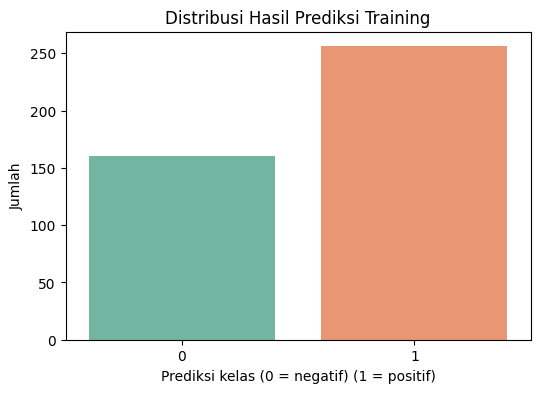

In [73]:
y_pred_train = tree.predict(X_train)

print("\nDistribusi Prediksi Training:")
print(pd.Series(y_pred_train).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_pred_train, palette="Set2")
plt.title("Distribusi Hasil Prediksi Training")
plt.xlabel("Prediksi kelas (0 = negatif) (1 = positif)")
plt.ylabel("Jumlah")
plt.show()

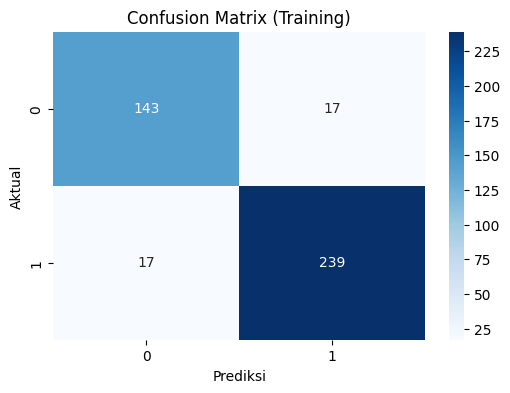

In [74]:
cm_train, classes = confusion_matrix_manual(y_train, y_pred_train)
plt.figure(figsize=(6,4))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Training)")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

2. testing model


Distribusi Prediksi Testing:
1    58
0    46
Name: count, dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_16532\1151472315.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred_test, palette="Set1")


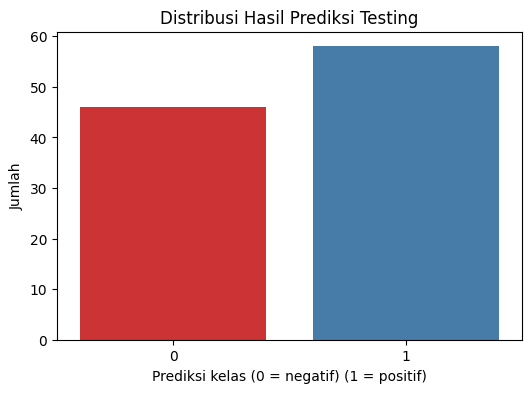

In [75]:
y_pred_test = tree.predict(X_test)

print("\nDistribusi Prediksi Testing:")
print(pd.Series(y_pred_test).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_pred_test, palette="Set1")
plt.title("Distribusi Hasil Prediksi Testing")
plt.xlabel("Prediksi kelas (0 = negatif) (1 = positif)")
plt.ylabel("Jumlah")
plt.show()

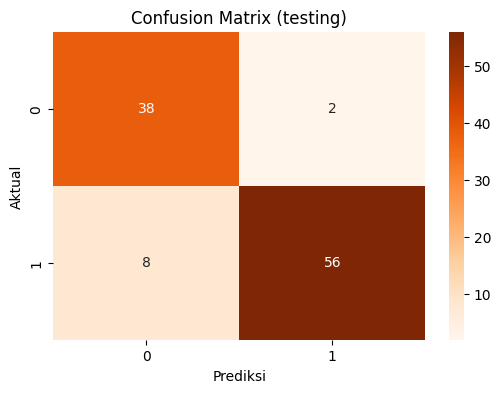

In [76]:
cm_test, classes = confusion_matrix_manual(y_test, y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Oranges", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (testing)")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

3. visualisasi pohon single mode

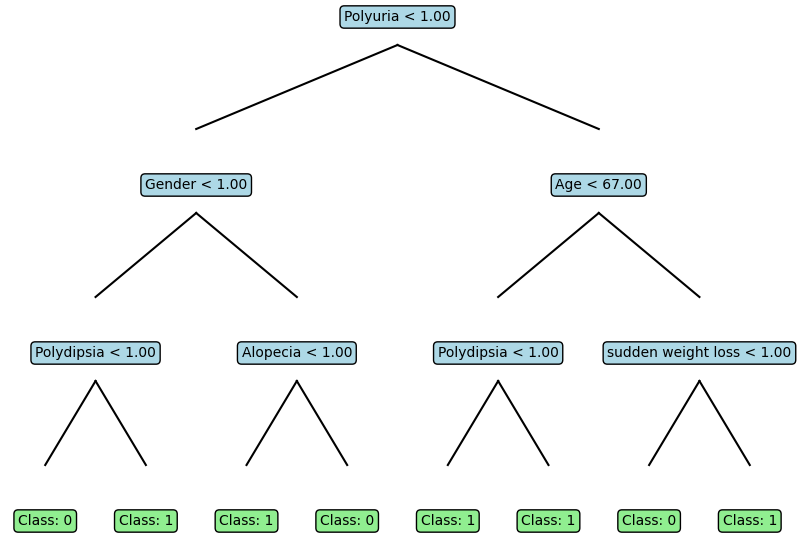

In [77]:
feature_names = list(dataset.drop("class", axis=1).columns)

plt.figure(figsize=(10, 6))
plot_tree(tree.root, feature_names)
plt.axis("off")
plt.show()

4. Analisi korelasi fitur dengan fitur (fitur kategorikal >> cramers_v)

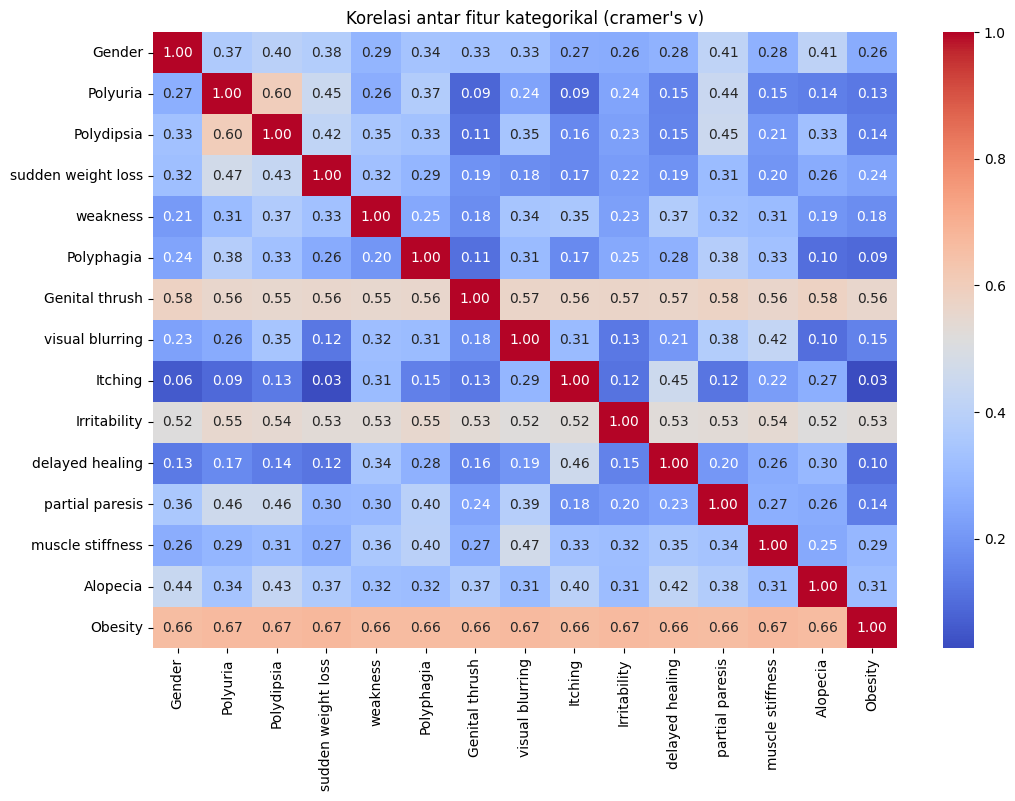

In [78]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = ((confusion - confusion.mean())**2 / confusion.mean()).sum().sum()
    n = confusion.sum().sum()
    r, k = confusion.shape 
    return np.sqrt((chi2 / n) / (min(k-1, r-1)))

categorical_cols = ['Gender','Polyuria','Polydipsia','sudden weight loss',
                    'weakness','Polyphagia','Genital thrush','visual blurring',
                    'Itching','Irritability','delayed healing','partial paresis',
                    'muscle stiffness','Alopecia','Obesity']

cramer_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols, dtype=float)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(dataset[col1], dataset[col2])

plt.figure(figsize=(12,8))
sns.heatmap(cramer_matrix.astype(float), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi antar fitur kategorikal (cramer's v)")
plt.show()

V. Evaluasi Model

In [79]:
def confusion_matrix_manual(y_true, y_pred):
    TP = sum((y_true == 1) & (y_pred == 1))
    TN = sum((y_true == 0) & (y_pred == 0))
    FP = sum((y_true == 0) & (y_pred == 1))
    FN = sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    TP, TN, FP, FN = confusion_matrix_manual(y_true, y_pred)

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score  = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n=== Evaluasi {dataset_name} ===")
    print(f"True Positive : {TP}")
    print(f"True Negative : {TN}")
    print(f"False Positive: {FP}")
    print(f"False Negative: {FN}")
    print(f"Akurasi  : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1_score:.4f}")
    
    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1_score}

1. Evaluasi Training Model

In [80]:
y_pred_train = tree.predict(X_train)
metrics_train = evaluate_model(y_train, y_pred_train, "Training")


=== Evaluasi Training ===
True Positive : 239
True Negative : 143
False Positive: 17
False Negative: 17
Akurasi  : 0.9183
Precision: 0.9336
Recall   : 0.9336
F1-Score : 0.9336


2. Evaluasi Testing Model

In [81]:
y_pred_test = tree.predict(X_test)
metrics_test = evaluate_model(y_test, y_pred_test, "Testing")


=== Evaluasi Testing ===
True Positive : 56
True Negative : 38
False Positive: 2
False Negative: 8
Akurasi  : 0.9038
Precision: 0.9655
Recall   : 0.8750
F1-Score : 0.9180


3. Bias dan Variance Model

In [82]:
def cross_val_bias_variance(model_class, X, y, k=5, max_depth=3, min_size=5, random_state=42):
    np.random.seed(random_state)
    n = len(y)
    indices = np.arange(n)
    np.random.shuffle(indices)
    fold_size = n // k

    errors = []

    for i in range(k):
        test_idx = indices[i*fold_size:(i+1)*fold_size]
        train_idx = np.delete(indices, np.arange(i*fold_size,(i+1)*fold_size))
        
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
        
        # Train model baru tiap fold
        model = model_class(max_depth=max_depth, min_size=min_size)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Hitung error (1 - akurasi)
        error = 1 - np.mean(y_pred == y_test)
        errors.append(error)

    bias = np.mean(errors)
    variance = np.var(errors)

    return bias, variance, errors

In [83]:
bias, variance, errors = cross_val_bias_variance(DecisionTreeClassifierCustom, X, y, k=5, max_depth=3, min_size=5)

In [84]:
print("Bias (rata-rata error):", round(bias,4))
print("Variance (variasi error antar fold):", round(variance,4))
print("Error tiap fold:", [round(e,4) for e in errors])

Bias (rata-rata error): 0.0808
Variance (variasi error antar fold): 0.0003
Error tiap fold: [np.float64(0.0577), np.float64(0.0865), np.float64(0.0673), np.float64(0.1058), np.float64(0.0865)]


VI. GUI

In [85]:
def to_terminal(group):
    if len(group) == 0:  # fallback kalau group kosong
        return 0  # atau 1, tergantung default class
    outcomes = [row[-1] for row in group]
    return max(set(outcomes), key=outcomes.count)

In [86]:
class DiabetesPredictApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Diabetes Prediction (Manual Input)")
        self.root.geometry("400x550")

        tk.Label(root, text="Input Data Pasien", font=("Arial", 14, "bold")).pack(pady=10)

        self.feature_cols = ['Polyuria', 'Polydipsia', 'sudden weight loss', 
                             'Itching', 'delayed healing', 'partial paresis']

        self.entries = {}
        for feature in self.feature_cols:
            frame = tk.Frame(root)
            frame.pack(pady=5, fill='x', padx=10)
            tk.Label(frame, text=f"{feature} (0/1):", width=20, anchor='w').pack(side='left')
            entry = tk.Entry(frame)
            entry.pack(side='left', fill='x', expand=True)
            self.entries[feature] = entry

        self.btn_predict = tk.Button(root, text="Predict", command=self.predict)
        self.btn_predict.pack(pady=10)

        self.txt_output = tk.Text(root, height=10, width=50)
        self.txt_output.pack(pady=10)

        self.model = DecisionTreeClassifierCustom(max_depth=3, min_size=5)

        self.model.fit(X_train, y_train)

    def predict(self):
        try:
            input_data = []
            for feature in self.feature_cols:
                val = self.entries[feature].get()
                if val not in ['0','1']:
                    messagebox.showerror("Input Error", f"{feature} harus 0 atau 1!")
                    return
                input_data.append(int(val))

            input_array = np.array([input_data])
            pred = self.model.predict(input_array)[0]
            result = "Positif Diabetes" if pred==1 else "Negatif Diabetes"

            self.txt_output.delete(1.0, tk.END)
            self.txt_output.insert(tk.END, f"Hasil Prediksi: {result}\n")

        except Exception as e:
            messagebox.showerror("Error", f"Gagal prediksi:\n{e}")

root = tk.Tk()
app = DiabetesPredictApp(root)
root.mainloop()
